# Analysis of Student Willingness-to-Pay for Premium Ed-Tech Tools

## Business Analytics Individual Case Study

**Dataset:** 10,928 public app reviews from Duolingo, Photomath and Brainly.

**Analytical focus:** Review-derived premium engagement and purchase-related signals.

> Important limitation: Public app reviews do not provide actual subscription transaction records or verified student demographics. Therefore, premium engagement is treated as a proxy derived from review text and app-review metadata, not as observed willingness-to-pay or actual conversion.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load Dataset

In [27]:
df = pd.read_csv("../data/processed/edtech_reviews_analysis.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10800, 41)


,app_id,appRating,appRatingCount,app_name,appUrl,appVersion,authorId,authorName,category,country,criteria,developer,installs,language,repliedAt,replyFrom,replyText,reviewId,reviewUrl,review_date,rating,scrapedAt,store,review_text,thumbs_up,review_text_clean,review_length,word_count,has_premium,has_purchase,has_price,has_free,has_cancel,has_limitation,engagement_score,engagement_level,premium_engagement_score,score,app,premium_engagement_level,text
0,com.duolingo,4.731,49102167,Duolingo: Language Lessons,https://play.google.com/store/apps/details?id=com.duolingo,6.95.4,117882355956252094989,GA Green,EDUCATION,us,NaN,Duolingo,500M+,en,NaN,NaN,NaN,5a75bedf-0aee-4e8e-bb2b-261683a4c936,https://play.google.com/store/apps/details?id=com.duolingo&reviewId=5a75bedf-0aee-4e8e-bb2b-261683a4c936,2026-09-10T20:31:09Z,4,2026-09-25T07:19:10.680629Z,google-play,very user friendly,2,very user friendly,18,3,0,0,0,0,0,0,0.105263,Medium,0.0,4,Duolingo,Medium,very user friendly
1,com.duolingo,4.731,49102167,Duolingo: Language Lessons,https://play.google.com/store/apps/details?id=com.duolingo,6.93.6,115610491850373274975,Shahrzad Shirazy,EDUCATION,us,NaN,Duolingo,500M+,en,NaN,NaN,NaN,0872bd93-3345-476f-b61c-fe357df5303c,https://play.google.com/store/apps/details?id=com.duolingo&reviewId=0872bd93-3345-476f-b61c-fe357df5303c,2026-08-30T13:27:30Z,1,2026-09-25T07:19:10.972458Z,google-play,denied the access to education right for Iranians is the most racist thing in this era you did shame on you,9,denied the access to education right for iranians is the most racist thing in this era you did shame on you,107,21,0,0,0,0,0,0,0.083333,Medium,0.0,1,Duolingo,Medium,denied the access to education right for Iranians is the most racist thing in this era you did shame on you
2,com.duolingo,4.731,49102167,Duolingo: Language Lessons,https://play.google.com/store/apps/details?id=com.duolingo,NaN,109909625603451025239,sa et,EDUCATION,us,NaN,Duolingo,500M+,en,NaN,NaN,NaN,77d6ca45-6525-43eb-bb78-e81364a842ac,https://play.google.com/store/apps/details?id=com.duolingo&reviewId=77d6ca45-6525-43eb-bb78-e81364a842ac,2026-08-30T13:03:38Z,1,2026-09-25T07:19:11.094606Z,google-play,"Duolingo’s treatment of Iranians and Persian speakers is disgraceful. Persian is one of the world’s major languages, spoken by millions, with countless people actively asking Duolingo to add it. Y...",9,"duolingo’s treatment of iranians and persian speakers is disgraceful. persian is one of the world’s major languages, spoken by millions, with countless people actively asking duolingo to add it. y...",485,71,0,0,0,0,0,0,0.018519,Medium,0.0,1,Duolingo,Medium,"Duolingo’s treatment of Iranians and Persian speakers is disgraceful. Persian is one of the world’s major languages, spoken by millions, with countless people actively asking Duolingo to add it. Y..."
3,com.duolingo,4.731,49102167,Duolingo: Language Lessons,https://play.google.com/store/apps/details?id=com.duolingo,NaN,113344961902557834739,Satyaprkash Chaudhary,EDUCATION,us,NaN,Duolingo,500M+,en,NaN,NaN,NaN,2b4a9139-0651-4bae-a71e-342f9ef76662,https://play.google.com/store/apps/details?id=com.duolingo&reviewId=2b4a9139-0651-4bae-a71e-342f9ef76662,2026-08-29T12:31:40Z,5,2026-09-25T07:19:11.206498Z,google-play,😀😀,5,😀😀,2,1,0,0,0,0,0,0,1.666667,High,0.0,5,Duolingo,High,😀😀
4,com.duolingo,4.731,49102167,Duolingo: Language Lessons,https://play.google.com/store/apps/details?id=com.duolingo,NaN,114779461416959794055,Reeta Yadav,EDUCATION,us,NaN,Duolingo,500M+,en,NaN,NaN,NaN,bd6b570b-6a6e-4132-9282-c38d7f691fae,https://play.google.com/store/apps/details?id=com.duolingo&reviewId=bd6b570b-6a6e-4132-9282-c38d7f691fae,2026-08-29T12:31:16Z,5,2026-09-25T07:19:11.243320Z,google-play,very good and awsome like i can learn every language in this aapp,4,very good and awsome like i can learn every language in this aapp,65,13,0,0,0,0,0,0,0.060606,Medium,0.0,5,Duolingo,Medium,very good and awsome like i can learn every language in this aapp


In [ ]:
## 3. Dataset Information

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Rows: 10800
Columns: 41

Data types:
app_id                       object
appRating                   float64
appRatingCount                int64
app_name                     object
appUrl                       object
appVersion                   object
authorId                     object
authorName                   object
category                     object
country                      object
criteria                     object
developer                    object
installs                     object
language                     object
repliedAt                    object
replyFrom                    object
replyText                    object
reviewId                     object
reviewUrl                    object
review_date                  object
rating                        int64
scrapedAt                    object
store                        object
review_text                  object
thumbs_up                     int64
review_text_clean            object
review_length              

## 4. Data Cleaning

In [5]:
# Create safe versions of fields used for analysis
df["text"] = df["text"].fillna("")
df["review_length"] = df["review_length"].fillna(0)
df["word_count"] = df["word_count"].fillna(0)
df["thumbs_up"] = df["thumbs_up"].fillna(0)

print("Missing text values after cleaning:", df["text"].isna().sum())
print("Missing thumbs_up values after cleaning:", df["thumbs_up"].isna().sum())


Missing text values after cleaning: 0
Missing thumbs_up values after cleaning: 0


## 5. Descriptive Statistics

In [6]:
df[[
    "score",
    "review_length",
    "word_count",
    "thumbs_up",
    "premium_engagement_score"
]].describe()


,score,review_length,word_count,thumbs_up,premium_engagement_score
count,10800.000000,10800.000000,10800.000000,10800.000000,10800.000000
mean,4.151389,55.234074,10.567778,1.286204,0.008565
std,1.444516,78.609059,14.631576,14.431719,0.057624
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4.000000,11.000000,2.000000,0.000000,0.000000
50%,5.000000,27.000000,5.000000,0.000000,0.000000
75%,5.000000,63.000000,12.000000,0.000000,0.000000
max,5.000000,500.000000,114.000000,714.000000,0.900000


## 6. Rating Distribution

score
1    1540
2     285
3     478
4    1194
5    7303
Name: count, dtype: int64


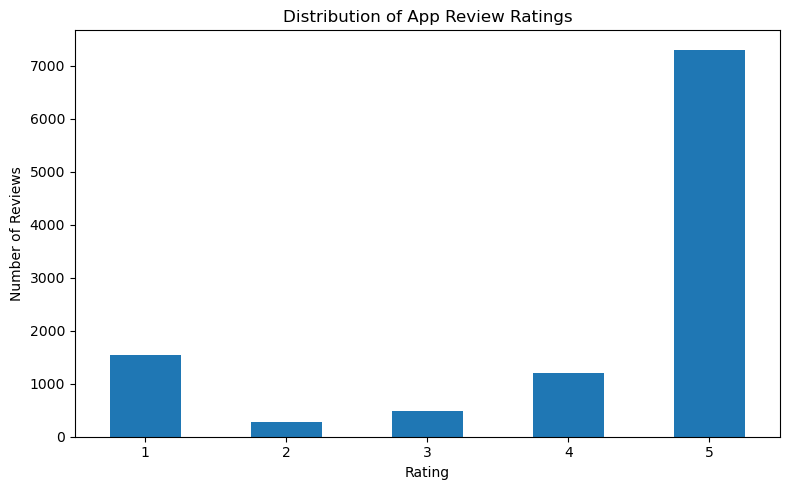

In [7]:
rating_counts = df["score"].value_counts().sort_index()

print(rating_counts)

plt.figure(figsize=(8,5))
rating_counts.plot(kind="bar")
plt.title("Distribution of App Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Reviews by App

app
Duolingo     3600
Photomath    3600
Brainly      3600
Name: count, dtype: int64


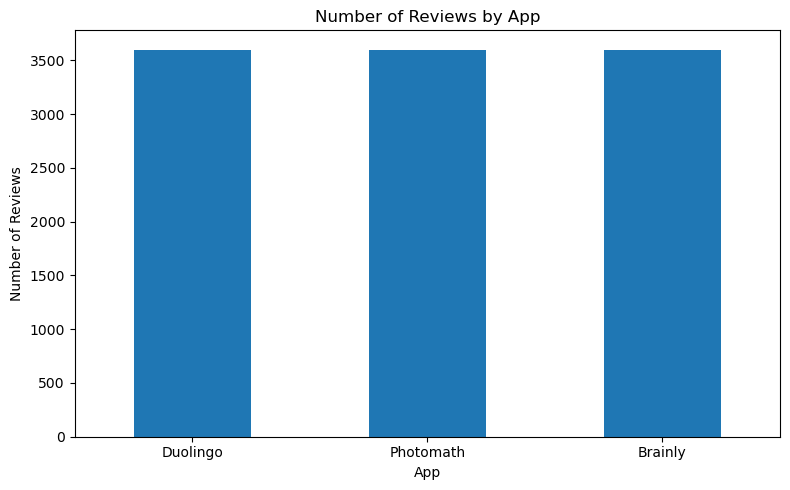

In [8]:
app_counts = df["app"].value_counts()

print(app_counts)

plt.figure(figsize=(8,5))
app_counts.plot(kind="bar")
plt.title("Number of Reviews by App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Average Rating by App

app
Duolingo     4.409
Brainly      4.273
Photomath    3.772
Name: score, dtype: float64


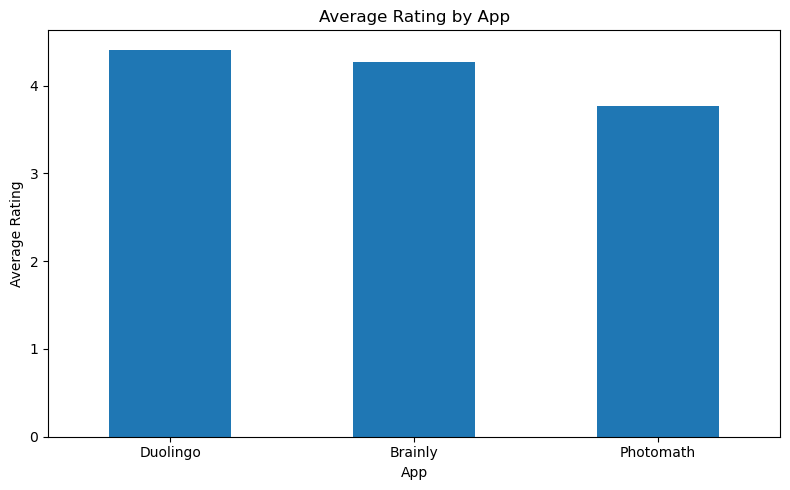

In [9]:
app_rating = df.groupby("app")["score"].mean().sort_values(ascending=False)

print(app_rating.round(3))

plt.figure(figsize=(8,5))
app_rating.plot(kind="bar")
plt.title("Average Rating by App")
plt.xlabel("App")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Premium Engagement Distribution

premium_engagement_level
Low       9713
Medium     979
High       108
Name: count, dtype: int64


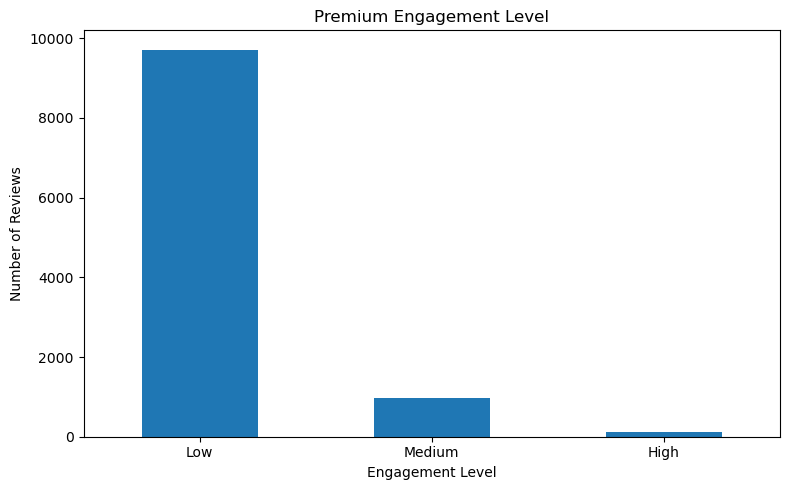

In [10]:
engagement_counts = (
    df["premium_engagement_level"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

print(engagement_counts)

plt.figure(figsize=(8,5))
engagement_counts.plot(kind="bar")
plt.title("Premium Engagement Level")
plt.xlabel("Engagement Level")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Premium Engagement by App

premium_engagement_level    Low  Medium  High
app                                          
Brainly                   89.75    9.36  0.89
Duolingo                  90.47    8.47  1.06
Photomath                 89.58    9.36  1.06


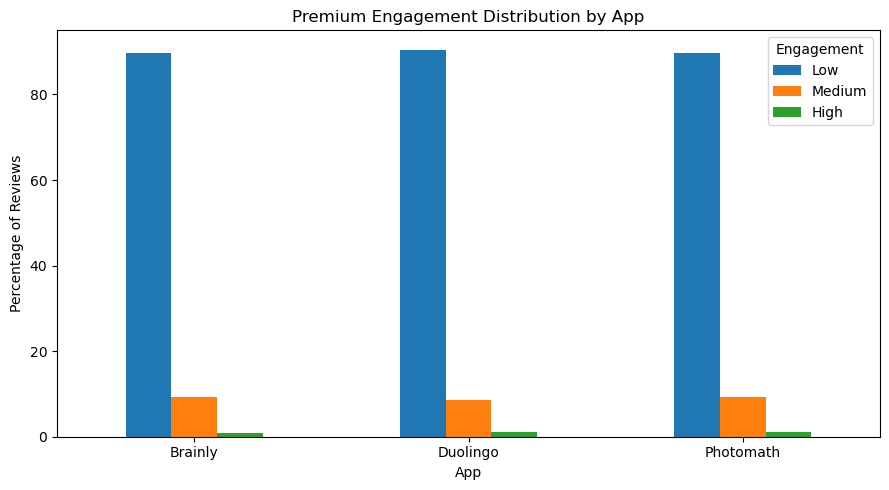

In [11]:
engagement_by_app = pd.crosstab(
    df["app"],
    df["premium_engagement_level"],
    normalize="index"
) * 100

engagement_by_app = engagement_by_app.reindex(
    columns=["Low", "Medium", "High"]
)

print(engagement_by_app.round(2))

engagement_by_app.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Premium Engagement Distribution by App")
plt.xlabel("App")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Engagement")
plt.tight_layout()
plt.show()


## 11. Premium Engagement by Rating

premium_engagement_level    Low  Medium  High
score                                        
1                         80.97   17.14  1.88
2                         83.51   15.09  1.40
3                         88.70   10.25  1.05
4                         89.87    8.88  1.26
5                         92.17    7.08  0.75


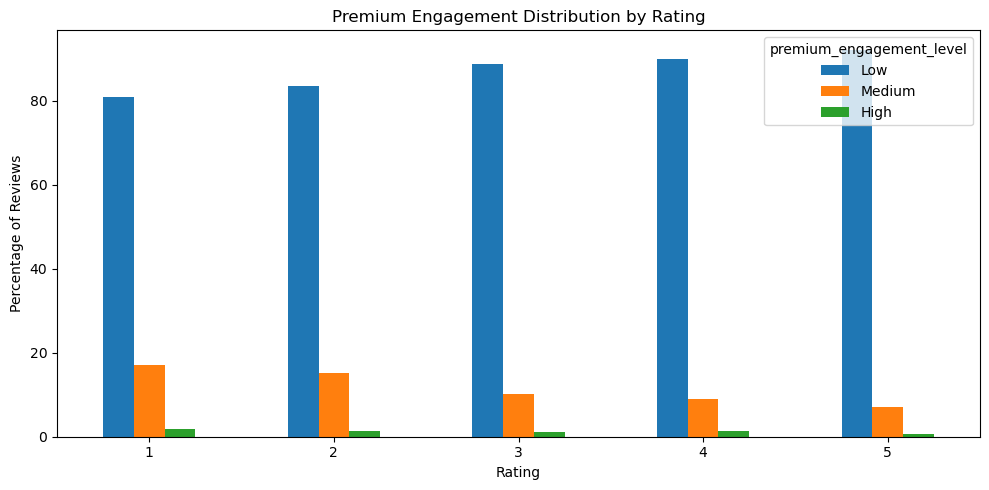

In [12]:
engagement_by_rating = pd.crosstab(
    df["score"],
    df["premium_engagement_level"],
    normalize="index"
) * 100

engagement_by_rating = engagement_by_rating.reindex(
    columns=["Low", "Medium", "High"]
)

print(engagement_by_rating.round(2))

engagement_by_rating.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Premium Engagement Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Average Rating by Engagement Level

In [13]:
rating_by_engagement = (
    df.groupby("premium_engagement_level")["score"]
    .agg(["count", "mean", "median"])
    .reindex(["Low", "Medium", "High"])
)

print(rating_by_engagement.round(3))


                          count   mean  median
premium_engagement_level                      
Low                        9713  4.215     5.0
Medium                      979  3.581     5.0
High                        108  3.583     5.0


## 13. Premium Signal Analysis

has_free          182
has_limitation    138
has_premium       110
has_purchase       83
has_price          49
has_cancel         22
dtype: int64


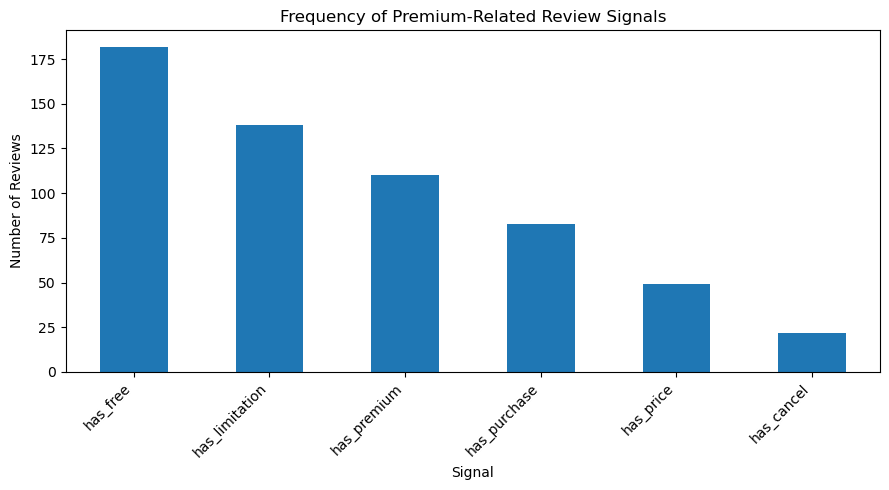

In [14]:
signal_columns = [
    "has_premium",
    "has_purchase",
    "has_price",
    "has_free",
    "has_cancel",
    "has_limitation"
]

signal_counts = df[signal_columns].sum().sort_values(ascending=False)

print(signal_counts)

plt.figure(figsize=(9,5))
signal_counts.plot(kind="bar")
plt.title("Frequency of Premium-Related Review Signals")
plt.xlabel("Signal")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 14. Review Length Analysis

count    10800.000000
mean        55.234074
std         78.609059
min          1.000000
25%         11.000000
50%         27.000000
75%         63.000000
max        500.000000
Name: review_length, dtype: float64


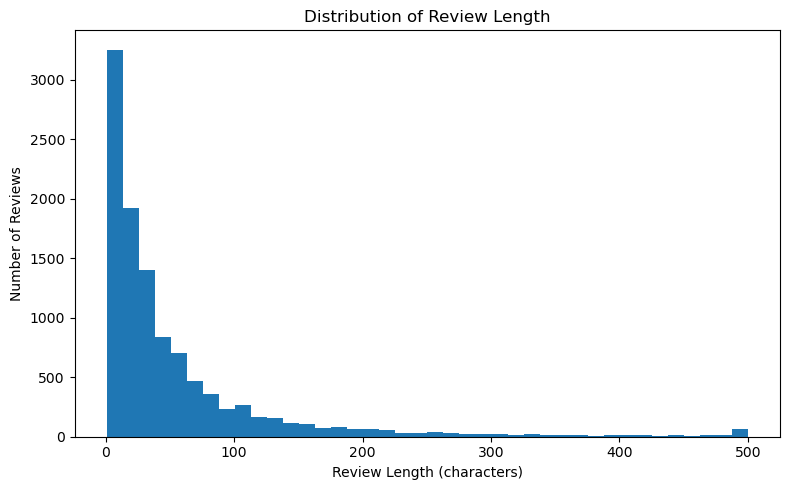

In [15]:
print(df["review_length"].describe())

plt.figure(figsize=(8,5))
plt.hist(df["review_length"], bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


## 15. App-Level Business Summary

In [16]:
summary = df.groupby("app").agg(
    reviews=("app", "size"),
    average_rating=("score", "mean"),
    average_review_length=("review_length", "mean"),
    average_premium_score=("premium_engagement_score", "mean"),
    high_engagement_reviews=(
        "premium_engagement_level",
        lambda x: (x == "High").sum()
    )
)

summary.round(3)

,reviews,average_rating,average_review_length,average_premium_score,high_engagement_reviews
app,,,,,
Brainly,3600,4.273,43.210,0.004,32
Duolingo,3600,4.409,62.580,0.009,38
Photomath,3600,3.772,59.912,0.013,38


## 16. Key Analytical Observations

In [17]:
print("Overall average rating:", round(df["score"].mean(), 3))
print("Total reviews:", len(df))

print("\nAverage rating by app:")
print(df.groupby("app")["score"].mean().round(3))

print("\nAverage premium engagement score by app:")
print(df.groupby("app")["premium_engagement_score"].mean().round(3))

print("\nHigh premium engagement reviews by app:")
print(
    df[df["premium_engagement_score"] >= 2]
    .groupby("app")
    .size()
)

print("\nHigh/Medium engagement percentage by rating:")
tmp = pd.crosstab(
    df["score"],
    df["premium_engagement_level"],
    normalize="index"
) * 100

tmp["Medium_or_High"] = tmp.get("Medium", 0) + tmp.get("High", 0)

print(tmp["Medium_or_High"].round(2))


Overall average rating: 4.151
Total reviews: 10800

Average rating by app:
app
Brainly      4.273
Duolingo     4.409
Photomath    3.772
Name: score, dtype: float64

Average premium engagement score by app:
app
Brainly      0.004
Duolingo     0.009
Photomath    0.013
Name: premium_engagement_score, dtype: float64

High premium engagement reviews by app:
Series([], dtype: int64)

High/Medium engagement percentage by rating:
score
1    19.03
2    16.49
3    11.30
4    10.13
5     7.83
Name: Medium_or_High, dtype: float64


## 17. Interpretation

The analysis examines associations between app-review characteristics and premium-related engagement.

The premium engagement score is a **proxy constructed from observable review language**, including references to premium subscriptions, payment, price, free access, cancellation and feature limitations.

The results should therefore not be interpreted as direct measurements of actual subscription conversion or individual willingness-to-pay.

The analysis is useful for identifying patterns in user feedback that may help Ed-Tech businesses understand where premium pricing, feature restrictions, advertising and subscription experiences are discussed most frequently.


## 18. Limitations

### Limitations

1. The dataset consists of public app reviews rather than verified subscription transactions.
2. Review authors are not verified as students.
3. Demographic variables such as age, course, income and year of study are not available.
4. Premium engagement is a text-derived proxy rather than observed willingness-to-pay.
5. The dataset covers three Ed-Tech applications: Duolingo, Photomath and Brainly.
6. Reviews are concentrated in the United States in this collected dataset.
7. The analysis identifies associations and should not be interpreted as causal evidence.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    "score",
    "review_length",
    "word_count",
    "thumbs_up",
    "app"
]

target = "premium_engagement_score"

X = df[features].copy()
y = df[target].copy()

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['score', 'review_length', 'word_count', 'thumbs_up', 'app']
Target: premium_engagement_score
X shape: (10800, 5)
y shape: (10800,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8640
Testing samples: 2160


In [20]:
numeric_features = [
    "score",
    "review_length",
    "word_count",
    "thumbs_up"
]

categorical_features = ["app"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

               Model     MAE    RMSE      R2
0  Linear Regression  0.0179  0.0557  0.0956
1      Decision Tree  0.0157  0.0578  0.0251
2      Random Forest  0.0164  0.0580  0.0202


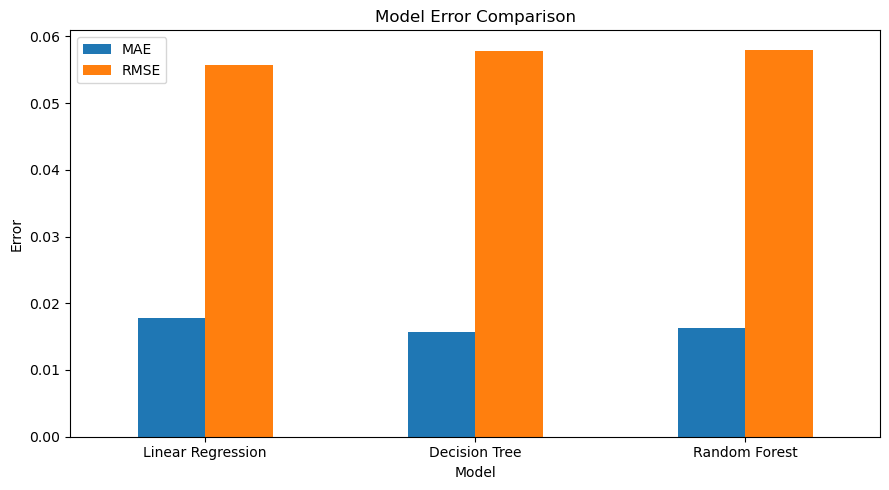

In [22]:
# Model comparison

results_plot = results_df.set_index("Model")

results_plot[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

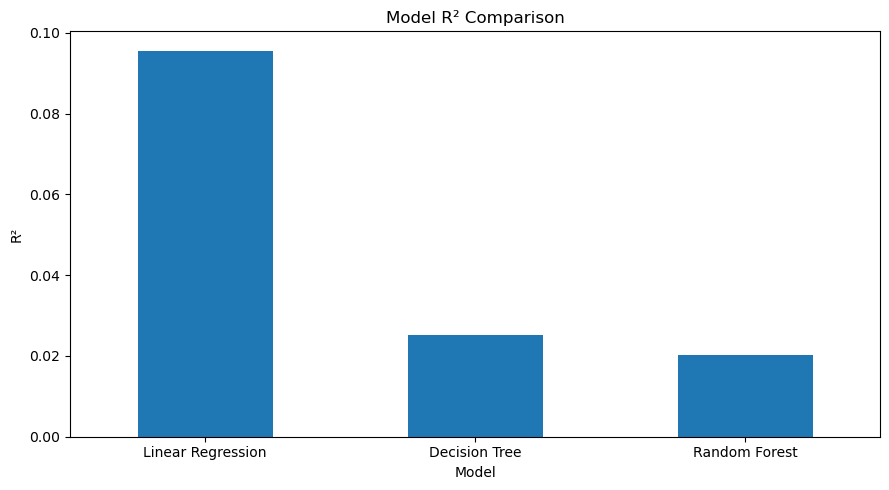

In [23]:
# R² comparison

results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Model R² Comparison")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 20. Model Interpretation

The three regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

Linear Regression produced an MAE of 0.0179, RMSE of 0.0557, and R² of 0.0956. Decision Tree produced an MAE of 0.0157, RMSE of 0.0578, and R² of 0.0251, while Random Forest produced an MAE of 0.0164, RMSE of 0.0580, and R² of 0.0202.

The results indicate that the available review metadata and basic text-length characteristics explain only a limited portion of the variation in the review-derived premium engagement score. The models should therefore be interpreted as exploratory predictive models rather than direct predictors of actual subscription conversion.

The limited R² values are consistent with the nature of the dataset. The target is a review-derived proxy constructed from textual references to premium features, payment, pricing, free access, cancellation and feature limitations rather than observed subscription transactions. Additional behavioural, demographic and transaction-level variables would be required for more direct conversion prediction.

## 21. Business Insights

The exploratory analysis provides several observations relevant to Ed-Tech subscription and premium-feature strategy.

- Premium-related engagement is concentrated in a relatively small proportion of reviews. The dataset contains 10,800 reviews, with 108 classified as High premium engagement and 979 classified as Medium engagement using the study's review-derived engagement classification.

- The three applications show different levels of premium-related engagement. Brainly has an average premium engagement score of 0.004, Duolingo 0.009, and Photomath 0.013. Photomath has the highest average score in this dataset, while Brainly has the lowest.

- The applications also differ in general review ratings. Duolingo has an average rating of 4.409, Brainly 4.273, and Photomath 3.772.

- Premium-related review language includes references to subscriptions, payment, pricing, free access, cancellation, advertisements and feature limitations. These textual signals provide useful information for understanding how users discuss premium experiences.

- The predictive models produced relatively limited R² values. This indicates that the basic review-level variables used in the models do not explain most of the variation in the review-derived premium engagement score.

From a business analytics perspective, the findings suggest that public review data can be used as an exploratory feedback-monitoring mechanism. However, transaction-level subscription data and verified user characteristics would be required for reliable individual-level conversion prediction.

## 22. Comparison with State-of-the-Art Methods

Recent research demonstrates different approaches for understanding technology adoption, willingness-to-pay, subscription-payment intention, and student perspectives toward digital education.

| Study | Dataset | Method | Evaluation Metric | Key Result | Comparison with This Study |
|---|---|---|---|---|---|
| Tyrväinen & Karjaluoto (2024) | Meta-analytical data from 55 studies and 15 qualitative interviews on freemium services | Mixed-method research and meta-analysis | Meta-analytic effect sizes and qualitative analysis | Perceived functional, hedonic, social, and price value were identified as predictors of willingness-to-pay. Trust also mediated relevant relationships. | Directly relevant to freemium and willingness-to-pay. The present study instead uses large-scale public app reviews and a review-derived proxy. |
| Veguru, Naren & Singam (2024) | Questionnaire responses from college students regarding online education | Machine-learning classification | Classification accuracy | Random Forest achieved a reported accuracy of 93% among the tested classification approaches. | Uses student-focused educational data and ML classification, whereas the present study uses public app reviews and regression modelling. |
| Liu, Park & Wang (2025) | 274 responses from ChatGPT users | Regression and moderated mediation analysis | Reliability, validity, regression, and moderated mediation analysis | Perceived usefulness positively influenced satisfaction and subscription-payment intention; satisfaction partially mediated the relationship. | Directly examines subscription-payment intention using survey data, whereas the present study uses 10,800 public reviews and a text-derived proxy. |

### Comparison with the Present Study

The present study differs from these studies mainly in its data source, target definition and analytical approach.

Instead of questionnaire responses, verified subscription transactions, or learner-level behavioural data, this study uses 10,800 publicly available Google Play reviews collected from three Ed-Tech applications: Duolingo, Photomath and Brainly.

The study constructs a review-derived `premium_engagement_score` using observable references to premium subscriptions, payment, pricing, free access, cancellation and feature limitations.

This score provides a scalable mechanism for analysing public user feedback, but it is not equivalent to observed subscription purchase behaviour or directly measured willingness-to-pay.

Unlike studies using survey, transaction or learner-level behavioural information, the present models use review rating, review length, word count, helpfulness and application identity as predictors while excluding the keyword indicators used to construct the target.

The relatively limited R² values indicate that these available predictors explain only a small portion of variation in the proxy target. This highlights the potential value of richer behavioural, demographic, survey and transaction-level information for direct prediction of subscription payment or willingness-to-pay.

## 22. Comparison with State-of-the-Art Methods

Recent research demonstrates different approaches for understanding technology adoption, willingness-to-pay, subscription-payment intention, and student perspectives toward digital education.

### Comparison with the Present Study

The present study differs from these studies mainly in its data source, target definition and analytical approach.

Instead of questionnaire responses, verified subscription transactions, or learner-level behavioural data, this study uses 10,800 publicly available Google Play reviews collected from three Ed-Tech applications: Duolingo, Photomath and Brainly.

The study constructs a review-derived premium_engagement_score using observable references to premium subscriptions, payment, pricing, free access, cancellation and feature limitations.

This score provides a scalable mechanism for analysing public user feedback, but it is not equivalent to observed subscription purchase behaviour or directly measured willingness-to-pay.

Unlike studies using survey, transaction or learner-level behavioural information, the present models use review rating, review length, word count, helpfulness and application identity as predictors while excluding the keyword indicators used to construct the target.

The relatively limited R² values indicate that these available predictors explain only a small portion of variation in the proxy target. This highlights the potential value of richer behavioural, demographic, survey and transaction-level information for direct prediction of subscription payment or willingness-to-pay.

## 23. Conclusion

This study analysed 10,800 publicly available Google Play reviews from Duolingo, Photomath and Brainly to investigate user discussions related to premium features, pricing and subscription experiences.

The exploratory analysis identified premium-related language involving subscriptions, payment, pricing, free access, cancellation and feature limitations. The three applications showed different levels of review-derived premium engagement, with average premium engagement scores of 0.004 for Brainly, 0.009 for Duolingo and 0.013 for Photomath.

Three regression models were developed using review rating, review length, word count, helpfulness and application identity as predictors of the review-derived premium engagement score. Linear Regression produced an R² of 0.0956, Decision Tree produced an R² of 0.0251 and Random Forest produced an R² of 0.0202. The results indicate that these basic review-level variables explain only a limited portion of variation in the proxy target.

The study demonstrates that publicly available review data can provide useful exploratory insights for Ed-Tech subscription and premium-feature analysis. However, the premium engagement score is a proxy and should not be interpreted as observed willingness-to-pay or confirmed subscription conversion.

Future work could incorporate verified transaction data, subscription history, usage frequency, user demographics, feature usage and other behavioural variables to develop more direct and reliable conversion prediction models.

## 24. Business Recommendations

Based on the exploratory analysis and predictive modelling results, the following recommendations can be considered by Ed-Tech platforms:

1. **Monitor premium-related user feedback**  
   Platforms can systematically analyse public reviews for references to subscriptions, pricing, payment, advertisements, feature restrictions and premium access. This can help identify recurring monetization-related concerns.

2. **Investigate application-specific premium feedback**  
   The three applications showed different levels of review-derived premium engagement. Platforms should therefore analyse application-specific feedback rather than assuming identical premium-related behaviour across products.

3. **Examine pricing and feature-access discussions**  
   References to price, free access, advertisements and feature limitations can be monitored as recurring themes in user feedback. These signals can support product and monetization discussions.

4. **Combine review data with behavioural data**  
   The relatively limited predictive performance indicates that review data alone is insufficient for direct conversion prediction. Combining review signals with usage frequency, subscription history, feature usage, demographics and transaction information could provide a stronger analytical basis.

5. **Use predictive models as decision-support tools**  
   The models developed in this study should be treated as exploratory analytical tools rather than direct predictors of actual willingness-to-pay or subscription conversion. Business decisions should incorporate additional verified customer and transaction-level information.

## 25. References

1. Tyrväinen, O., & Karjaluoto, H. (2024). Willingness to pay for freemium services: Addressing the differences between monetization strategies. *International Journal of Information Management, 77*, 102787. https://doi.org/10.1016/j.ijinfomgt.2024.102787

2. Veguru, H. S. K., Naren, J., & Singam, Y. (2024). Student's Interest and Opinion Towards Online Education. *Procedia Computer Science, 233*, 590–596. https://doi.org/10.1016/j.procs.2024.03.248

3. Liu, Y., Park, Y., & Wang, H. (2025). The mediating effect of user satisfaction and the moderated mediating effect of AI anxiety on the relationship between perceived usefulness and subscription payment intention. *Journal of Retailing and Consumer Services, 84*, 104176. https://doi.org/10.1016/j.jretconser.2024.104176

4. Google Play. (2026). Public user reviews for Duolingo, Photomath and Brainly collected through web scraping for this study.